In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA

In [3]:
X = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algorithm/credit card.csv')

# 불필요한 컬럼 삭제
# 'CUST_ID'(고객 아이디)는 단순 식별용 번호이며, 모델 학습에 방해가 되므로 제거
X = X.drop('CUST_ID', axis=1)

# 결측치 처리
# fillna(method='ffill'): 결측치가 있는 경우 바로 앞 행의 값으로 채운다.
# inplace=True: 변경 사항을 데이터프레임 X에 즉시 적용하라는 뜻
X.fillna(method='ffill', inplace=True)
print(X.head())

       BALANCE  BALANCE_FREQUENCY  ...  PRC_FULL_PAYMENT  TENURE
0    40.900749           0.818182  ...          0.000000      12
1  3202.467416           0.909091  ...          0.222222      12
2  2495.148862           1.000000  ...          0.000000      12
3  1666.670542           0.636364  ...          0.000000      12
4   817.714335           1.000000  ...          0.000000      12

[5 rows x 17 columns]


/tmp/ipykernel_3315/823661872.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method='ffill', inplace=True)


In [6]:
# 데이터 표준화
# 각 변수의 평균을 0, 표준편차를 1로 맞춘다.
# 특정 변수의 단위가 너무 커서 모델이 왜곡되는 것을 방지한다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 정규화
# 각 행(고객별 데이터)의 크기를 1로 맞춘다. (L2 Normalization)
# 데이터의 절대적 크기보다 변수 간의 상대적 비율이나 방향이 중요할 때 사용
X_normalized = normalize(X_scaled)
X_normalized = pd.DataFrame(X_normalized)

# 주성분 분석(PCA)을 통한 차원 축소
# 원래 수십 개였던 변수들을 정보 손실을 최소화하면서 2개(P1, P2)의 새로운 축으로 압축
# n_components=2: 2차원 평면에 시각화하기 위함
pca = PCA(n_components=2)
X_principal = pca.fit_transform(X_normalized)

X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']
print(X_principal.head())

         P1        P2
0 -0.489949 -0.679976
1 -0.519099  0.544827
2  0.330633  0.268879
3 -0.481656 -0.097611
4 -0.563512 -0.482506


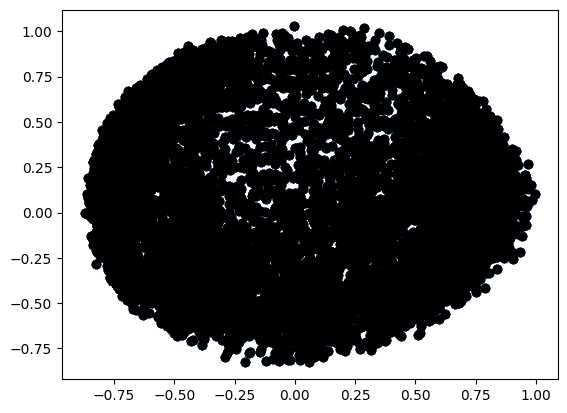

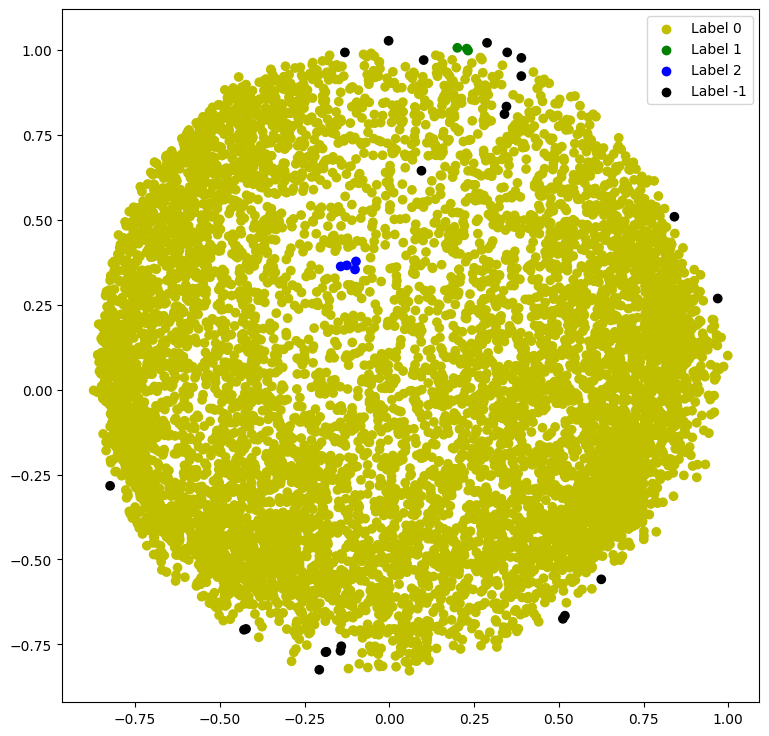

In [8]:
# eps(epsilon): 이웃을 정의하는 반지름 거리. 이 거리 안에 데이터가 있어야 같은 팀으로 봄
# min_samples: 한 팀(군집)이 되기 위해 필요한 최소 데이터 개수
db_default = DBSCAN(eps=0.0375, min_samples=3).fit(X_principal)
labels = db_default.labels_

# -1은 어느 군집에도 속하지 못한 노이즈(Outlier) 데이터로, 검은색(k)으로 표시
colours = {0: 'y', 1: 'g', 2: 'b', -1: 'k'}

cvec = [colours[label] for label in labels]

r = plt.scatter(X_principal['P1'], X_principal['P2'], color='y')
g = plt.scatter(X_principal['P1'], X_principal['P2'], color='g')
b = plt.scatter(X_principal['P1'], X_principal['P2'], color='b')
k = plt.scatter(X_principal['P1'], X_principal['P2'], color='k')

plt.figure(figsize=(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)

plt.legend((r, g, b, k), ('Label 0', 'Label 1', 'Label 2', 'Label -1'))
plt.show()

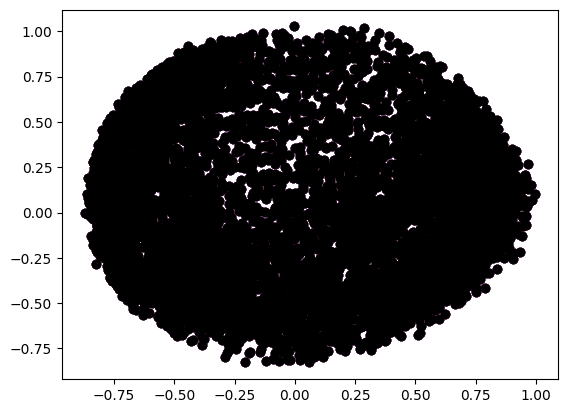

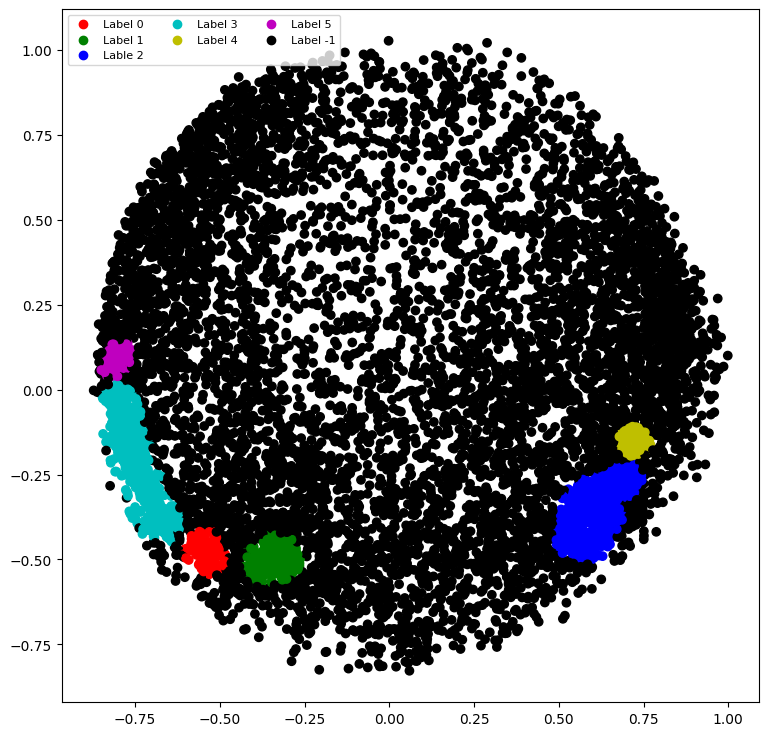

In [9]:
# DBSCAN 모델 생성 및 학습(조건 강화)
# min_samples=50: 최소 50개의 데이터가 뭉쳐 있어야 하나의 군집으로 인정한다.
# 이 값이 커질수록 자잘한 뭉텅이들은 군집이 아닌 노이즈(-1)로 처리될 확률이 높다.
db = DBSCAN(eps=0.0375, min_samples=50).fit(X_principal)
labels1 = db.labels_

colours1 = {0: 'r', 1: 'g', 2: 'b', 3: 'c', 4: 'y', 5: 'm', -1: 'k'}

cvec = [colours1[label] for label in labels1]
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k']

r = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[0])
g = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[1])
b = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[2])
c = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[3])
y = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[4])
m = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[5])
k = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[6])

plt.figure(figsize=(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)
plt.legend((r, g, b, c, y, m, k), ('Label 0', 'Label 1', 'Lable 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'),
           scatterpoints=1,
           loc='upper left',
           ncol=3,
           fontsize=8)
plt.show()

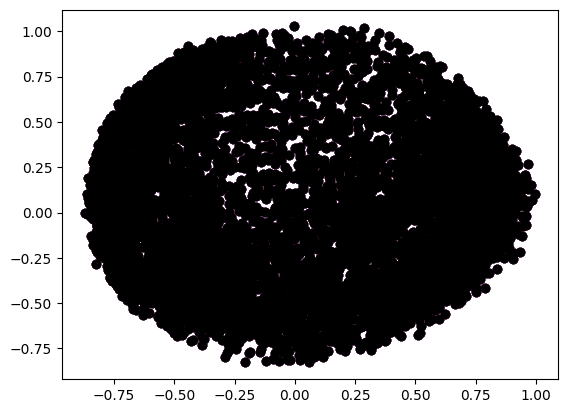

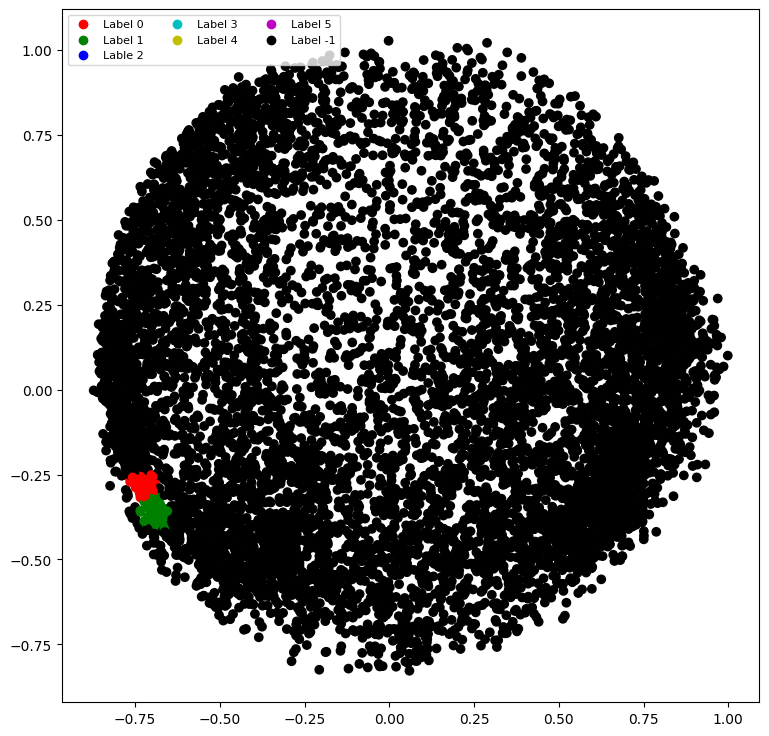

In [10]:
# min_samples=100: 50에서 100으로 변경
db = DBSCAN(eps=0.0375, min_samples=100).fit(X_principal)
labels1 = db.labels_

colours1 = {0: 'r', 1: 'g', 2: 'b', 3: 'c', 4: 'y', 5: 'm', -1: 'k'}

cvec = [colours1[label] for label in labels1]
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k']

r = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[0])
g = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[1])
b = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[2])
c = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[3])
y = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[4])
m = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[5])
k = plt.scatter(X_principal['P1'], X_principal['P2'], marker='o', color=colors1[6])

plt.figure(figsize=(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)
plt.legend((r, g, b, c, y, m, k), ('Label 0', 'Label 1', 'Lable 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'),
           scatterpoints=1,
           loc='upper left',
           ncol=3,
           fontsize=8)
plt.show()